# Primera parte

## Los Datos

In [1]:
download.file("http://www.openintro.org/stat/data/mlb11.RData", destfile = "mlb11.RData")

load("mlb11.RData")

#### Pregunta 1

Para mostrar la relación entre runs y at_bats se utiliza un diagrama de dispersión, ya que ambas variables son numéricas.

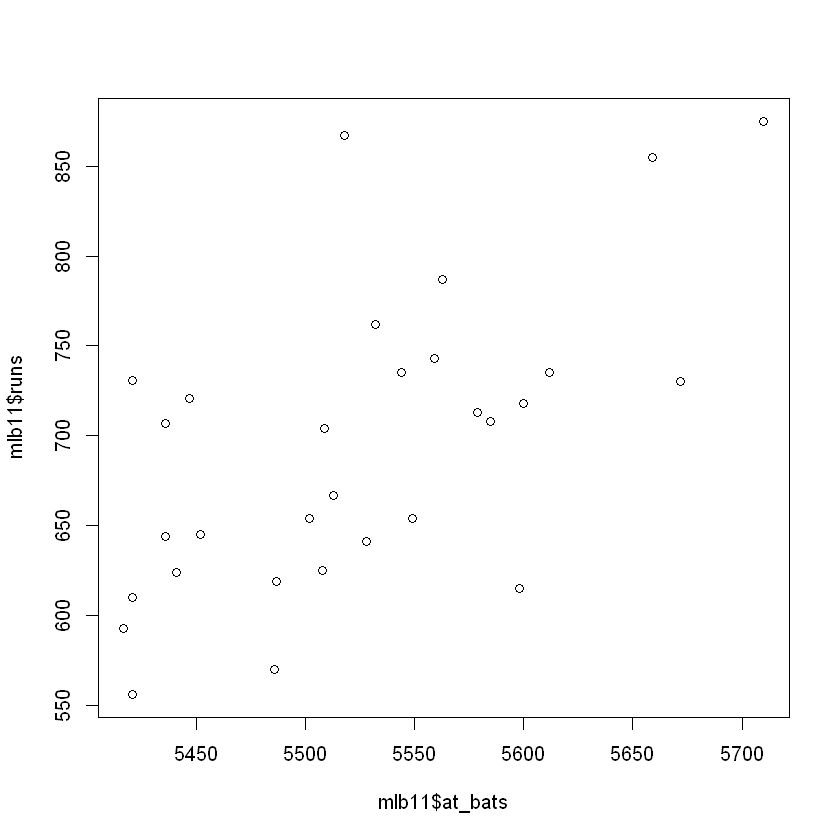

In [2]:

plot(mlb11$runs ~ mlb11$at_bats)


La relación entre runs y at_bats parece positiva y aproximadamente lineal, ya que al aumentar at_bats, en general también aumenta runs.

In [3]:
cor(mlb11$runs, mlb11$at_bats)

[1] 0.610627

## Suma de residuos al cuadrado

#### Pregunta 2

Usando plot_ss, elija una línea que minimice bien la suma de los cuadrados. Ejecute la función varias veces. ¿Cuál fue la menor suma de cuadrados que obtuvo? Incluya el gráfico obtenido con plot_ss con showSquares = TRUE.

                                
Call:
lm(formula = y ~ x, data = pts)

Coefficients:
(Intercept)            x  
 -2789.2429       0.6305  

Sum of Squares:  123721.9

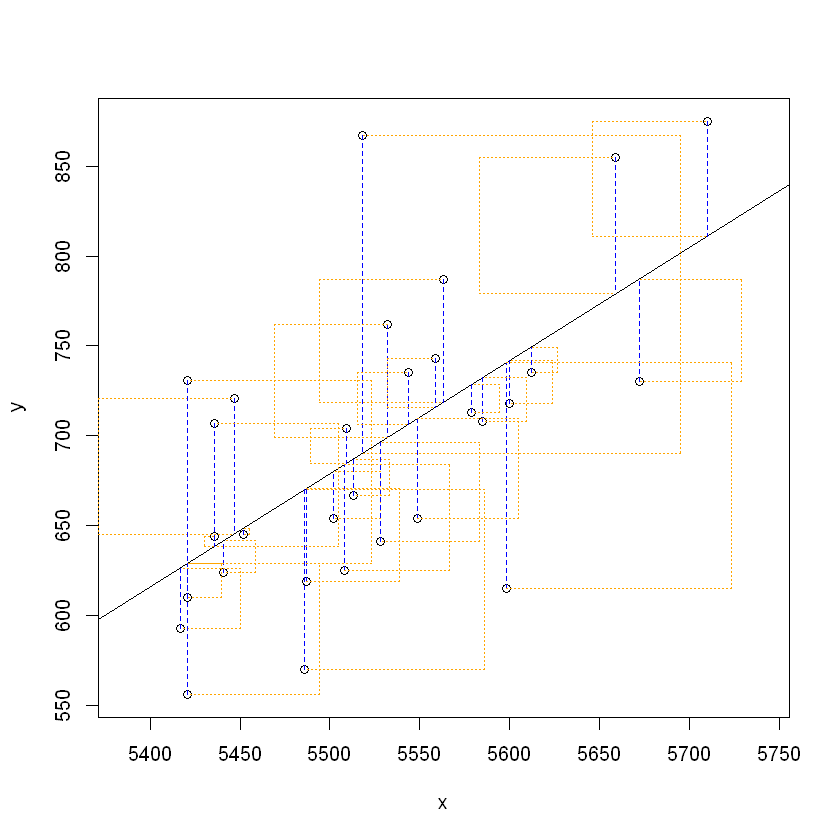

In [12]:
plot_ss(x = mlb11$at_bats, y = mlb11$runs, showSquares = TRUE)

La menor suma de cuadrados obtenida fue de 123721.9, con una intersección de 2789.2429 y una pendiente de 0.6305.

## El modelo lineal


#### Pregunta 3


In [14]:
m1 <- lm(runs ~ at_bats, data = mlb11)
summary(m1)


Call:
lm(formula = runs ~ at_bats, data = mlb11)

Residuals:
    Min      1Q  Median      3Q     Max 
-125.58  -47.05  -16.59   54.40  176.87 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2789.2429   853.6957  -3.267 0.002871 ** 
at_bats         0.6305     0.1545   4.080 0.000339 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 66.47 on 28 degrees of freedom
Multiple R-squared:  0.3729,	Adjusted R-squared:  0.3505 
F-statistic: 16.65 on 1 and 28 DF,  p-value: 0.0003388


#### Pregunta 4

La intersección es -2789.2429 y la pendiente es 0.6305 (primera columna de los coeficientes). Eso haría que la fórmula sea:
$$\hat{y}=-2789.2429+0.6305\cdot at\_bats$$

## Predicción y errores de predicción

#### Pregunta 6

Copie el gráfico con la línea de mínimos cuadrados en el reporte (el que acaba de generar).

In [ ]:
plot(mlb11$runs ~ mlb11$at_bats)
abline(m1)

## Comprobación de supuestos

### 1. Linealidad


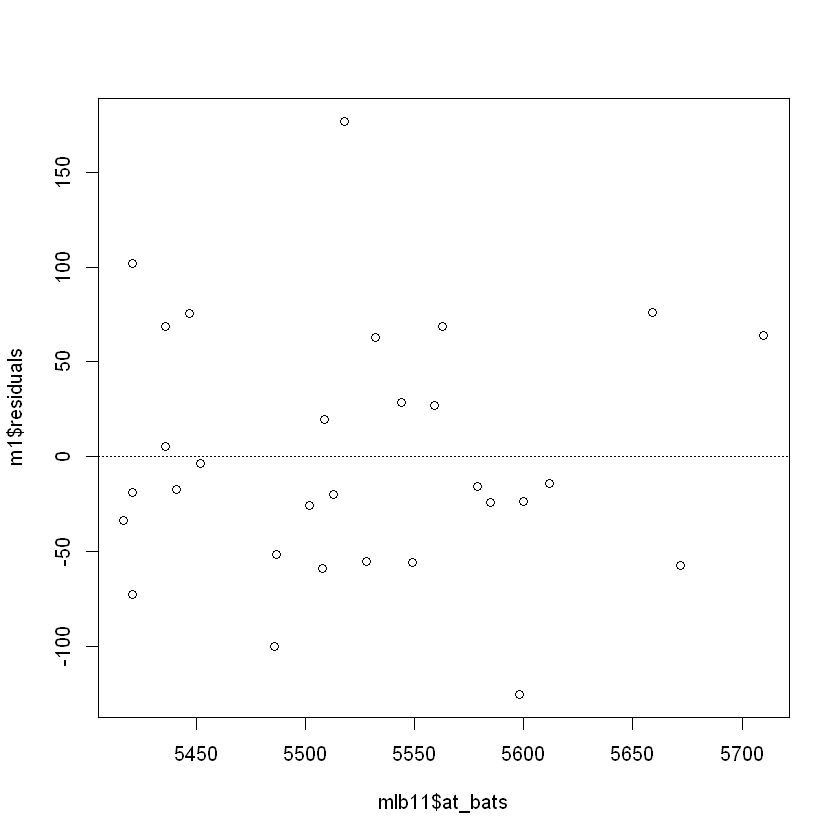

In [ ]:

plot(m1$residuals ~ mlb11$at_bats)
abline(h = 0, lty = 3) # adds a horizontal dashed line at y = 0

#### Pregunta 7
¿Hay algún patrón aparente en el gráfico de residuos? ¿Qué indica esto acerca de la
linealidad de la relación entre runs y at_bats?

No se puede observar algun patron particular en el grafico de residuos, lo que sugiere que la relación entre runs y at_bats es razonablemente lineal.

#### Pregunta 8

En el histograma se podría decir que los datos parecen seguir algo la distribución normal porque la mayoría de los datos se concentra en los valores centrales, aunque sí se puede notar que no es simétrica. En el Q-Q se puede observar que los datos se quedan cerca de la línea de normalidad. Entonces parece que la condición de residuos casi normales sí se podría cumplir.

## Segunda Parte



#### Pregunta 10

Elija otra variable tradicional de mlb11 que crea que podría ser un buen predictor de runs. Produzca un diagrama de dispersión de las dos variables y ajuste un modelo lineal. De un vistazo, ¿parece haber una relación lineal?


Call:
lm(formula = runs ~ hits, data = mlb11)

Residuals:
     Min       1Q   Median       3Q      Max 
-103.718  -27.179   -5.233   19.322  140.693 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -375.5600   151.1806  -2.484   0.0192 *  
hits           0.7589     0.1071   7.085 1.04e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 50.23 on 28 degrees of freedom
Multiple R-squared:  0.6419,	Adjusted R-squared:  0.6292 
F-statistic:  50.2 on 1 and 28 DF,  p-value: 1.043e-07


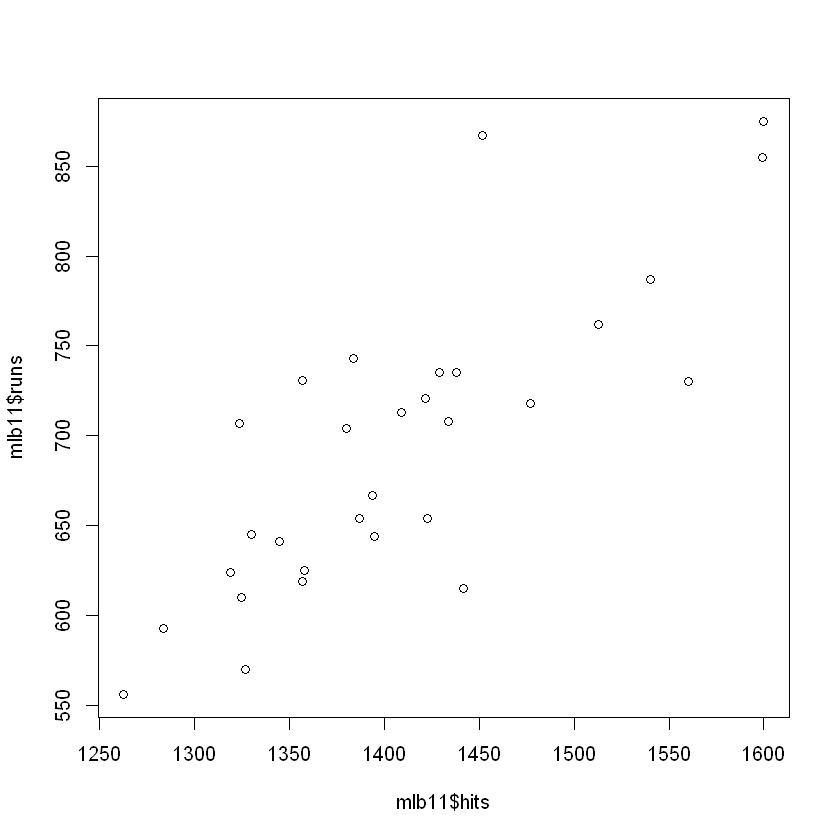

In [17]:
plot(mlb11$runs ~ mlb11$hits)
m2 <- lm(runs ~ hits, data = mlb11)
summary(m2)

Se eligió la variable hits como predictor. En el gráfico se logra ver una regresión lineal positiva al utilizar hits como predictor, ya que conforme la cantidad de hits auentan, también lo hacen los runs, aunque con un poco de dispersión como logra observarse. Dicho eso, la formula acabaría siendo:
$$\hat{y}=-375.56+0.7589\cdot hits$$


#### Pregunta 11
¿Cómo se compara esta relación con la relación entre runs y at_bats? Utilice los valores
Múltiplo R-cuadrado de los dos resúmenes de modelos para comparar. ¿Su variable parece predecir runs
mejor que at_bats? ¿Cómo puede saberlo?

| *runs* ~ *at_bats* | *runs* ~ *hits* |
|----------------|-------------|
| Multiple R-squared:  0.3729 | Multiple R-squared:  0.6419 |

Se puede observar que la presicion con la que el modelo predice *runs* es mejor con *hits* que con *at_bats*, ya que el *Multiple R-squared* es mayor en el modelo con *hits* (0.6419) comparado con el modelo con *at_bats* (0.3729), siendo casi que el doble. Esto indica que *hits* es un mejor predictor de *runs* que *at_bats*.

Esto porque el $R^2$ indica la proporción de la varianza en la variable dependiente, que es predecible a partir de la variable independiente. Un valor más alto de $R^2$ indica un mejor ajuste del modelo a los datos, lo que significa que el predictor elegido *hits* explica una mayor proporción de la variabilidad en *runs* en comparación con *at_bats*.

#### Pregunta 12
Ahora que puede resumir la relación lineal entre dos variables, investigue las relaciones
entre runs y cada una de las otras cinco variables tradicionales. ¿Qué variable predice mejor las corridas?
Apoye su conclusión usando los métodos gráficos y numéricos que hemos discutido (en aras de la
concisión, solo incluya resultados para la mejor variable, no para las cinco).